# IMP NOTE: Exploratory Data Analysis steps executed via custom .py files 
1. data_quality_check.py
2. pca_implementation.py
3. clustering_implementation.py

# 1. Import libraries and read the dataset

In [1]:
# import libraries
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
%matplotlib inline
import seaborn as seabornInstance 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
# import custom .py files
from data_quality_check import data_quality_check
from pca_implementation import pca_implementation
from clustering_implementation import clustering_kmeans

In [2]:
# read original data
dataset = pd.read_csv("kc_house_data.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [3]:
# drop columns - 'id', 'date', 'zipcode'
df = dataset.drop(['id', 'date', 'zipcode'], 1)
#df.info()

# 2. Explore Data Analysis. Find out how one variable related to other and distributions of data.

# 3. State your insights

In [4]:
# data overview
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.141767,367127.196483,75000.0000,321950.000,450000.0000,645000.000,7.700000e+06
bedrooms,21613.0,3.370842,0.930062,0.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.114757,0.770163,0.0000,1.750,2.2500,2.500,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000,1.5000,2.000,3.500000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000,0.0000,0.000,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000,0.0000,0.000,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000,3.0000,4.000,5.000000e+00
grade,21613.0,7.656873,1.175459,1.0000,7.000,7.0000,8.000,1.300000e+01


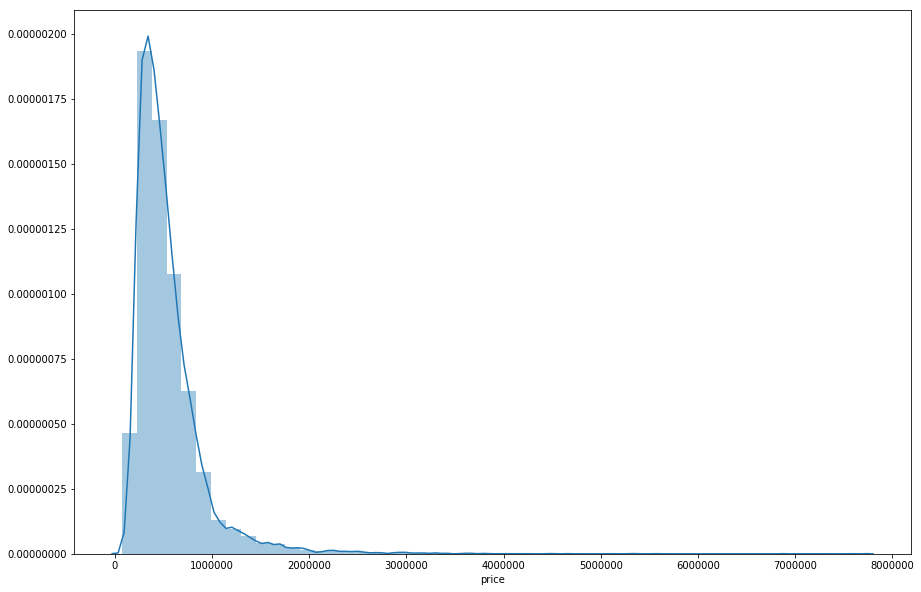

In [5]:
# understand target variable distribution
plt.figure(figsize=(15,10))
plt.tight_layout()
seabornInstance.distplot(df['price'])

## OBSERVATIONS:
1. Outliers noticed for various columns, scaling required
2. Certain variables are binary in nature = waterfront, view, sqft_basement
3. bedrooms and yr_renovated need feature engineering
3. Price (target variable) has long tail

In [6]:
# DATA QUALITY CHECK (import data_quality_check)
data_quality_check()


    ---------------------------------------------------------------------------------------
    ================================== DATA QUALITY CHECK =================================
    ---------------------------------------------------------------------------------------
    DATAFRAME TYPE: Structured data
    ---------------------------------------------------------------------------------------
    FUNCTION: Provide information overview, drop columns, alter dtypes, one-hot encoding &
    missing data summary
    ---------------------------------------------------------------------------------------
    INPUTS REQUIRED: Information in pandas dataframe
    ---------------------------------------------------------------------------------------
    
PFB is the list of databases to choose from...
kchousedata20190714015356565841_dqm.csv
kchousedata20190714015356565841_dqm_customfeatures.csv
kc_house_data.csv

----------------------------------------------------------------------------

OBSERVATIONS/NOTES: NA
------------------------------------------------------------------------------------
STEP 3: Outliers detection to identify preprocessing steps
------------------------------------------------------------------------------------
ACTION - Review significant outliers present and overall information loss if outliers excluded
(Note: Certain algorithms don't need outlier treatments - example SVM)
Column-wise outliers range captured:
                 count          mean           std           min  \
id             21613.0  4.580302e+09  2.876566e+09  1.000102e+06   
price          21613.0  5.400881e+05  3.671272e+05  7.500000e+04   
bedrooms       21613.0  3.370842e+00  9.300618e-01  0.000000e+00   
bathrooms      21613.0  2.114757e+00  7.701632e-01  0.000000e+00   
sqft_living    21613.0  2.079900e+03  9.184409e+02  2.900000e+02   
sqft_lot       21613.0  1.510697e+04  4.142051e+04  5.200000e+02   
floors         21613.0  1.494309e+00  5.399889e-01  1.000000e+00   
w

Enter column name/s (one at a time): grade
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): sqft_above
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): sqft_basement
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): yr_built
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): lat
-------------------------------------------------------------------

Select Treatment for sqft_above (int): 2
---------------------------------------------------------------------------------------
count    21613.000000
mean       291.509045
std        442.575043
min          0.000000
25%          0.000000
50%          0.000000
75%        560.000000
max       4820.000000
Name: sqft_basement, dtype: float64
Options available #1: Scaling the information with StandardScaler(0), MinMaxScaler(1) or RobustScaler(2)- opt.2 suggested if data has outliers
Options available #2: Binning the information with KBinsDiscretizer(3), Binarizer(4)
---------------------------------------------------------------------------------------
Select Treatment for sqft_basement (int): 4
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Set threshold for binary categorization (float): 1
------------------------------------------------------------------------

OBSERVATIONS/NOTES: Original variables need to be dropped at a later stage
------------------------------------------------------------------------------------
STEP 5: Categorical variables treatment
------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
QUESTION: Any object variable that needs one-hot(1) / label(2) encoding (N if not applicable(N))? N
---------------------------------------------------------------------------------------
OBSERVATIONS/NOTES: NA
------------------------------------------------------------------------------------
STEP 6: Dataframe columns finalization
------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
QUESTION: Any columns that need to be excluded (Y/N)? Y
---------------------------------------------------------------

## Model based on customized features, scaling of existing variables, PCA implementation

In [7]:
# read processed data generated from the above step
df = pd.read_csv('kchousedata20190714021348206830_dqm.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 34 columns):
price                         21613 non-null float64
bedrooms                      21613 non-null int64
bathrooms                     21613 non-null float64
sqft_living                   21613 non-null int64
sqft_lot                      21613 non-null int64
floors                        21613 non-null float64
waterfront                    21613 non-null int64
view                          21613 non-null int64
condition                     21613 non-null int64
grade                         21613 non-null int64
sqft_above                    21613 non-null int64
sqft_basement                 21613 non-null int64
yr_built                      21613 non-null int64
yr_renovated                  21613 non-null int64
lat                           21613 non-null float64
long                          21613 non-null float64
sqft_living15                 21613 non-null int64
sqft_lot15    

In [8]:
# feature engineer yr_renovated to capture refurbished age (years since last renovated/built)
df['feature_age'] = 2015 - df[['yr_built', 'yr_renovated']].max(axis=1)
df['feature_age'].describe()

count    21613.000000
mean        41.613982
std         28.806854
min          0.000000
25%         16.000000
50%         38.000000
75%         61.000000
max        115.000000
Name: feature_age, dtype: float64

In [9]:
# add scaled new feature back to df
sca = RobustScaler()
X = df[['feature_age']]
X = sca.fit_transform(X)
a = pd.DataFrame(X)
column_name = 'feature_age_robustscaled'
a.columns = [column_name]
df[column_name]= a[column_name]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 36 columns):
price                         21613 non-null float64
bedrooms                      21613 non-null int64
bathrooms                     21613 non-null float64
sqft_living                   21613 non-null int64
sqft_lot                      21613 non-null int64
floors                        21613 non-null float64
waterfront                    21613 non-null int64
view                          21613 non-null int64
condition                     21613 non-null int64
grade                         21613 non-null int64
sqft_above                    21613 non-null int64
sqft_basement                 21613 non-null int64
yr_built                      21613 non-null int64
yr_renovated                  21613 non-null int64
lat                           21613 non-null float64
long                          21613 non-null float64
sqft_living15                 21613 non-null int64
sqft_lot15    

In [10]:
# cap bedrooms greater than 6 as 6 to avoid outliers  
df['bedrooms'].value_counts()

3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
8       13
0       13
9        6
10       3
11       1
33       1
Name: bedrooms, dtype: int64

In [11]:
df['bedrooms_capped'] = df['bedrooms'].apply(lambda x: 6 if x >= 6 else x)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_above_robustscaled,sqft_basement_binaryscaled,yr_built_minmaxscaled,lat_robustscaled,long_robustscaled,sqft_living15_robustscaled,sqft_lot15_robustscaled,feature_age,feature_age_robustscaled,bedrooms_capped
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,-0.372549,0,0.478261,-0.292754,-0.133005,-0.574713,-0.395344,60,0.488889,3
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,0.598039,1,0.443478,0.720773,-0.438424,-0.172414,0.003813,24,-0.311111,3
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,-0.774510,0,0.286957,0.802415,-0.014778,1.011494,0.088702,82,0.977778,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,-0.500000,1,0.565217,-0.246377,-0.802956,-0.551724,-0.525788,50,0.266667,4
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0.117647,0,0.756522,0.217391,0.911330,-0.045977,-0.023480,28,-0.222222,3


In [12]:
# add scaled new feature back to df
sca = MinMaxScaler()
X = df[['bedrooms_capped']]
X = sca.fit_transform(X)
a = pd.DataFrame(X)
column_name = 'bedrooms_capped_minmaxscaled'
a.columns = [column_name]
df[column_name]= a[column_name]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 38 columns):
price                           21613 non-null float64
bedrooms                        21613 non-null int64
bathrooms                       21613 non-null float64
sqft_living                     21613 non-null int64
sqft_lot                        21613 non-null int64
floors                          21613 non-null float64
waterfront                      21613 non-null int64
view                            21613 non-null int64
condition                       21613 non-null int64
grade                           21613 non-null int64
sqft_above                      21613 non-null int64
sqft_basement                   21613 non-null int64
yr_built                        21613 non-null int64
yr_renovated                    21613 non-null int64
lat                             21613 non-null float64
long                            21613 non-null float64
sqft_living15                   2

In [13]:
# drop other unnecessary columns
drop_list = ['bedrooms', 'bedrooms_capped', 'feature_age', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
             'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 
             'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
df_training = df.drop(drop_list,1)
df_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price                           21613 non-null float64
outlier_filter_flag             21613 non-null int64
bathrooms_robustscaled          21613 non-null float64
sqft_living_robustscaled        21613 non-null float64
sqft_lot_robustscaled           21613 non-null float64
floors_minmaxscaled             21613 non-null float64
waterfront_binaryscaled         21613 non-null int64
view_binaryscaled               21613 non-null int64
condition_minmaxscaled          21613 non-null float64
grade_robustscaled              21613 non-null float64
sqft_above_robustscaled         21613 non-null float64
sqft_basement_binaryscaled      21613 non-null int64
yr_built_minmaxscaled           21613 non-null float64
lat_robustscaled                21613 non-null float64
long_robustscaled               21613 non-null float64
sqft_living15_robustscaled      21613 non-null float64
sqft_lot15_robustsc

In [14]:
# export file for future reference
df_training.to_csv("kchousedata20190714021348206830_dqm_customfeatures.csv", index=False)

In [15]:
# CORRELATION AND PCA CHECK (import pca_implementation)
pca_implementation()


    ---------------------------------------------------------------------------------------
    ================================ IDENTIFY AND TRAIN PCA ===============================
    ---------------------------------------------------------------------------------------
    DATAFRAME TYPE: Preprocessed, structured data
    ---------------------------------------------------------------------------------------
    FUNCTION: PCA implementation, Correlation metrics, Dataframe modifications
    ---------------------------------------------------------------------------------------
    INPUTS REQUIRED: Information in pandas dataframe
    ---------------------------------------------------------------------------------------
    
PFB is the list of databases to choose from...
kchousedata20190714021348206830_dqm.csv
kchousedata20190714021348206830_dqm_customfeatures.csv
kc_house_data.csv

---------------------------------------------------------------------------------------
Please sele

QUESTION: Any columns that need to be excluded (Y/N)? Y
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter number of columns to be dropped : 7
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): sqft_lot_robustscaled
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): sqft_lot15_robustscaled
---------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------
Enter column name/s (one at a time): grade_robustscaled
----------------------

None
PFB is the list of databases to choose from...
kchousedata20190714021348206830dqmcustomfeatures20190714021746103307_pca.csv
kchousedata20190714021348206830_dqm.csv
kchousedata20190714021348206830_dqm_customfeatures.csv
kc_house_data.csv

---------------------------------------------------------------------------------------
Please select a dataframe for exploratory data analysis: kchousedata20190714021348206830dqmcustomfeatures20190714021746103307_pca
---------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 15 columns):
price                           21613 non-null float64
outlier_filter_flag             21613 non-null int64
floors_minmaxscaled             21613 non-null float64
waterfront_binaryscaled         21613 non-null int64
view_binaryscaled               21613 non-null int64
condition_minmaxscaled          21613 non-null float64
sqft_basement_bina

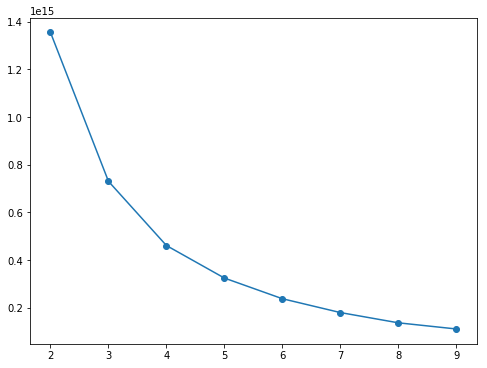

In [17]:
# CLUSTERING CHECK - see if the information can be broken down into meaningful clusters
clustering_kmeans(df)

# 4. Build a linear regression model to predict the house prices

## Building base model for performance evaluation (original df without any modifications)

In [18]:
# drop columns - 'id', 'date', 'zipcode'
df_original = dataset.drop(['id', 'date', 'zipcode'], 1)

In [19]:
# divide the data into “attributes” - X and “labels” - y
X = df_original.drop('price', 1).values
y = df_original['price'].values

# X as dataframe for reference
X_dataframe = df_original.drop('price', 1)

In [20]:
# split 80% of the data to training set while 20% of the data to test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [21]:
# train our model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [22]:
# Coefficients generated
coeff_df = pd.DataFrame(regressor.coef_, X_dataframe.columns, columns=['Coefficient'])  
coeff_df

,Coefficient
bedrooms,-32586.148762
bathrooms,39202.168286
sqft_living,109.937233
sqft_lot,0.082444
floors,8051.051352
waterfront,603130.004224
view,48708.074954
condition,31812.697830
grade,95465.104456
sqft_above,67.826329


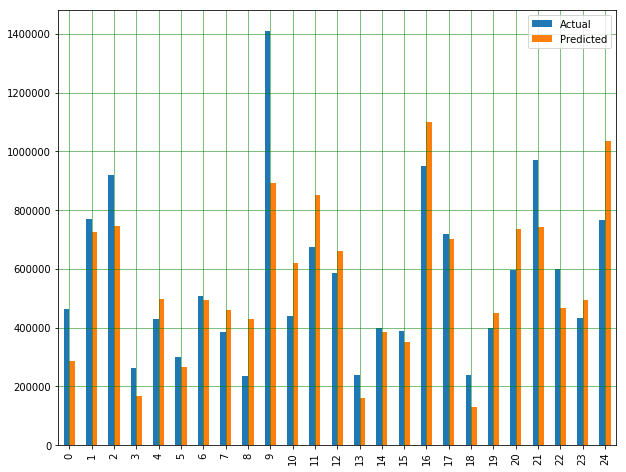

In [23]:
# prediction on test data
y_pred = regressor.predict(X_test)
df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1 = df_results.head(25)
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [24]:
## test the model performance
def linRegcheckModelPerformance(x, y):
    model = LinearRegression()
    # Covert data into train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
                                                        random_state = 7)
    # Build model with train data set
    model.fit(x_train, y_train)
    # Train accuracies
    trainR2 = model.score(x_train, y_train)
    predictedSales = model.predict(x_train)
    mse = metrics.mean_squared_error(predictedSales, y_train)
    trainRmse = np.sqrt(mse)
    trainRmsePct = trainRmse/np.mean(np.mean(np.array(y_train)))*100
    trainAdjR2 = AdjRsquare(model, x_train, y_train)
    trainAccuracies = [len(y_train), trainRmse, trainRmsePct, trainR2, trainAdjR2]
    # Test accuracies
    testR2 = model.score(x_test, y_test)
    predictedSales = model.predict(x_test)
    mse = metrics.mean_squared_error(predictedSales, y_test)
    testRmse = np.sqrt(mse)
    testRmsePct = testRmse/np.mean(np.mean(np.array(y_test)))*100
    testAdjR2 = AdjRsquare(model, x_test, y_test)
    testAccuracies = [len(y_test), testRmse, testRmsePct, testR2, testAdjR2]
    # Create dataframe for results
    resultsDf = pd.DataFrame(index = ["dataSize", "rmse", "rmsePct", "r2", "adjR2"])
    resultsDf['trainData'] = trainAccuracies
    resultsDf['testData'] = testAccuracies
    return ( round(resultsDf, 4))

## Adjusted R^2
def AdjRsquare(modelToBeTested, indData, target):
    Rsquare = modelToBeTested.score(indData, target)
    NoData = len(target)
    p = indData.shape[1]
    tempRsquare = 1 - (1-Rsquare)*(NoData-1)/(NoData - p - 1)
    return tempRsquare

In [25]:
linRegcheckModelPerformance(X, y)

,trainData,testData
dataSize,17290.0000,4323.0000
rmse,201841.2211,205911.7599
rmsePct,37.3464,38.2300
r2,0.6992,0.6792
adjR2,0.6989,0.6779


In [26]:
# cross validation using 10 k-folds (explained variance/r2)
print(cross_val_score(regressor, X, y, scoring='explained_variance', cv=10))

[0.69274163 0.69356424 0.68440185 0.68863751 0.67940632 0.698025
 0.70777814 0.70257159 0.69662314 0.68674064]


In [27]:
# cross validation using 10 k-folds (MSE)
print(cross_val_score(regressor, X, y, scoring='neg_mean_absolute_error', cv=10))

[-128426.64890871 -130171.79027616 -123111.16758474 -128828.20644373
 -116772.73516131 -126446.02102671 -124618.69999591 -130839.07969128
 -127835.12449745 -133213.15053053]


# 5. Try to find out important features or create new features to improve the performance for your model

# 6.Use appropriate cross validations techniques to find out the best predictor parameters and best prediction

## Approaches tried below and outcomes noted
1. Non-clustered but featurized training data set to check if any improvements attainable beyond base iteration
Outcome - Not much improvement noted although refined features provided same performance
2. Data clustered into 2 groups (core group cluster_0 of 19833 which covers maximum of target variable distribution while cluster_1 represents groups of houses with high price range)
Outcome - While cluster_1 failed, cluster_0 showcased considerable improvement in performance (RMSE % reduced from 38% to 23%) 

## Non-clustered but featurized linear regression performance check

In [50]:
# read finalized dataframe for prediction study
dataset = pd.read_csv('kchousedata20190714021348206830dqmcustomfeatures20190714021746103307_pca.csv')
dataset.head()

,price,outlier_filter_flag,floors_minmaxscaled,waterfront_binaryscaled,view_binaryscaled,condition_minmaxscaled,sqft_basement_binaryscaled,yr_built_minmaxscaled,lat_robustscaled,long_robustscaled,feature_age_robustscaled,bedrooms_capped_minmaxscaled,PCA_0,PCA_1,PCA_2
0,221900.0,0,0.0,0,0,0.5,0,0.478261,-0.292754,-0.133005,0.488889,0.500000,-2.262324,0.320175,-1.903386
1,538000.0,1,0.4,0,0,0.5,1,0.443478,0.720773,-0.438424,-0.311111,0.500000,-1.731753,0.080467,0.085378
2,180000.0,0,0.0,0,0,0.5,0,0.286957,0.802415,-0.014778,0.977778,0.333333,-1.369639,0.345701,-2.336208
3,604000.0,0,0.0,0,0,1.0,1,0.565217,-0.246377,-0.802956,0.266667,0.666667,-2.402493,0.342307,-0.442491
4,510000.0,0,0.0,0,0,0.5,0,0.756522,0.217391,0.911330,-0.222222,0.500000,-1.615456,0.176969,0.058336


In [51]:
# divide the data into “attributes” - X and “labels” - y
X = dataset.drop('price', 1).values
y = dataset['price'].values

# X as dataframe for reference
X_dataframe = dataset.drop('price', 1)

In [52]:
# split 80% of the data to training set while 20% of the data to test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [53]:
# train our model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [54]:
# Coefficients generated
coeff_df = pd.DataFrame(regressor.coef_, X_dataframe.columns, columns=['Coefficient'])  
coeff_df

,Coefficient
outlier_filter_flag,23889.287341
floors_minmaxscaled,-27453.062030
waterfront_binaryscaled,694113.912736
view_binaryscaled,80647.914777
condition_minmaxscaled,134770.338351
sqft_basement_binaryscaled,13907.426759
yr_built_minmaxscaled,-364621.773428
lat_robustscaled,111826.481984
long_robustscaled,-46999.899892
feature_age_robustscaled,19840.888449


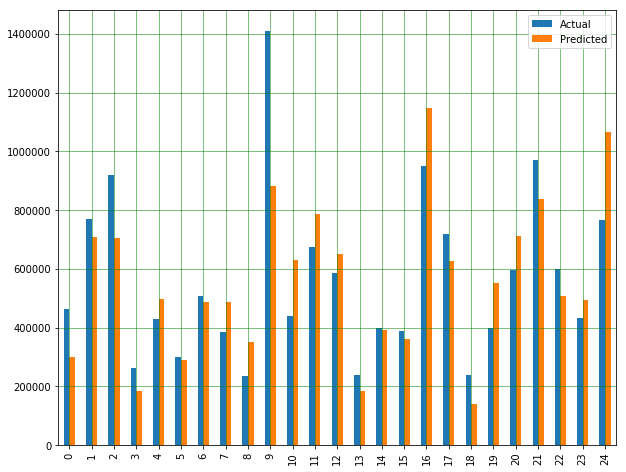

In [55]:
# prediction on test data
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1 = df.head(25)
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [56]:
# check results
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 130160.20098946519
Mean Squared Error: 43430598271.41753
Root Mean Squared Error: 208400.0918219988


In [57]:
## test the model performance
def linRegcheckModelPerformance(x, y):
    model = LinearRegression()
    # Covert data into train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
                                                        random_state = 7)
    # Build model with train data set
    model.fit(x_train, y_train)
    # Train accuracies
    trainR2 = model.score(x_train, y_train)
    predictedSales = model.predict(x_train)
    mse = metrics.mean_squared_error(predictedSales, y_train)
    trainRmse = np.sqrt(mse)
    trainRmsePct = trainRmse/np.mean(np.mean(np.array(y_train)))*100
    trainAdjR2 = AdjRsquare(model, x_train, y_train)
    trainAccuracies = [len(y_train), trainRmse, trainRmsePct, trainR2, trainAdjR2]
    # Test accuracies
    testR2 = model.score(x_test, y_test)
    predictedSales = model.predict(x_test)
    mse = metrics.mean_squared_error(predictedSales, y_test)
    testRmse = np.sqrt(mse)
    testRmsePct = testRmse/np.mean(np.mean(np.array(y_test)))*100
    testAdjR2 = AdjRsquare(model, x_test, y_test)
    testAccuracies = [len(y_test), testRmse, testRmsePct, testR2, testAdjR2]
    # Create dataframe for results
    resultsDf = pd.DataFrame(index = ["dataSize", "rmse", "rmsePct", "r2", "adjR2"])
    resultsDf['trainData'] = trainAccuracies
    resultsDf['testData'] = testAccuracies
    return ( round(resultsDf, 4))

## Adjusted R^2
def AdjRsquare(modelToBeTested, indData, target):
    Rsquare = modelToBeTested.score(indData, target)
    NoData = len(target)
    p = indData.shape[1]
    tempRsquare = 1 - (1-Rsquare)*(NoData-1)/(NoData - p - 1)
    return tempRsquare

In [58]:
linRegcheckModelPerformance(X, y)

,trainData,testData
dataSize,17290.0000,4323.0000
rmse,204821.7652,208400.0918
rmsePct,37.8979,38.6920
r2,0.6902,0.6714
adjR2,0.6900,0.6703


In [59]:
print(cross_val_score(regressor, X, y, scoring='explained_variance', cv=10))

[0.68021709 0.68302822 0.67248144 0.67075603 0.67119861 0.69580729
 0.70545343 0.70625592 0.68603205 0.6826427 ]


In [60]:
print(cross_val_score(regressor, X, y, scoring='neg_mean_absolute_error', cv=10))

[-130840.67001837 -131352.09219632 -125628.90384219 -131296.4250727
 -118845.43968007 -127468.24231951 -124868.58391738 -130777.77050175
 -131389.28656908 -133094.90520343]


## Cluster_0 linear regression performance check

In [28]:
# read finalized dataframe for prediction study
dataset = pd.read_csv('kchousedata20190714021348206830dqmcustomfeatures20190714021746103307pca20190714021900640608_Cluster_0.csv')
dataset.head()

,price,outlier_filter_flag,floors_minmaxscaled,waterfront_binaryscaled,view_binaryscaled,condition_minmaxscaled,sqft_basement_binaryscaled,yr_built_minmaxscaled,lat_robustscaled,long_robustscaled,feature_age_robustscaled,bedrooms_capped_minmaxscaled,PCA_0,PCA_1,PCA_2,GROUP_kmeans
0,221900.0,0,0.0,0,0,0.5,0,0.478261,-0.292754,-0.133005,0.488889,0.500000,-2.262324,0.320175,-1.903386,0
1,538000.0,1,0.4,0,0,0.5,1,0.443478,0.720773,-0.438424,-0.311111,0.500000,-1.731753,0.080467,0.085378,0
2,180000.0,0,0.0,0,0,0.5,0,0.286957,0.802415,-0.014778,0.977778,0.333333,-1.369639,0.345701,-2.336208,0
3,604000.0,0,0.0,0,0,1.0,1,0.565217,-0.246377,-0.802956,0.266667,0.666667,-2.402493,0.342307,-0.442491,0
4,510000.0,0,0.0,0,0,0.5,0,0.756522,0.217391,0.911330,-0.222222,0.500000,-1.615456,0.176969,0.058336,0


In [29]:
# divide the data into “attributes” - X and “labels” - y
X = dataset.drop('price', 1).values
y = dataset['price'].values

# X as dataframe for reference
X_dataframe = dataset.drop('price', 1)

In [30]:
# split 80% of the data to training set while 20% of the data to test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [31]:
# train our model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [32]:
# Coefficients generated
coeff_df = pd.DataFrame(regressor.coef_, X_dataframe.columns, columns=['Coefficient'])  
coeff_df

,Coefficient
outlier_filter_flag,-5191.708490
floors_minmaxscaled,42583.036664
waterfront_binaryscaled,140665.936282
view_binaryscaled,52681.113522
condition_minmaxscaled,92568.286737
sqft_basement_binaryscaled,20632.294901
yr_built_minmaxscaled,-233683.689327
lat_robustscaled,106357.700939
long_robustscaled,-6726.177956
feature_age_robustscaled,10677.545565


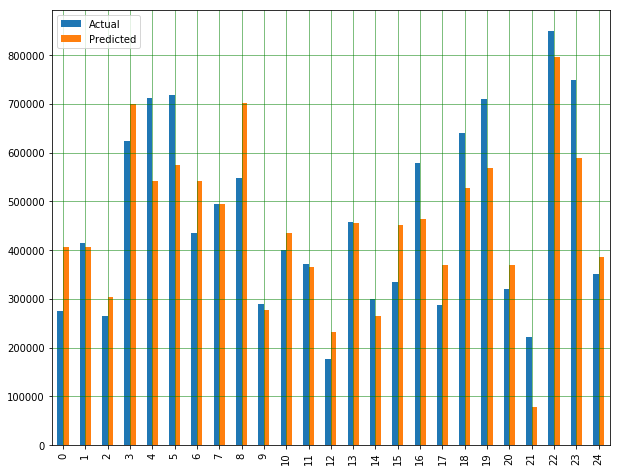

In [33]:
# prediction on test data
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1 = df.head(25)
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [34]:
# check results
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 81791.86641340876
Mean Squared Error: 11453280393.981287
Root Mean Squared Error: 107019.99997188043


In [35]:
## test the model performance
def linRegcheckModelPerformance(x, y):
    model = LinearRegression()
    # Covert data into train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
                                                        random_state = 7)
    # Build model with train data set
    model.fit(x_train, y_train)
    # Train accuracies
    trainR2 = model.score(x_train, y_train)
    predictedSales = model.predict(x_train)
    mse = metrics.mean_squared_error(predictedSales, y_train)
    trainRmse = np.sqrt(mse)
    trainRmsePct = trainRmse/np.mean(np.mean(np.array(y_train)))*100
    trainAdjR2 = AdjRsquare(model, x_train, y_train)
    trainAccuracies = [len(y_train), trainRmse, trainRmsePct, trainR2, trainAdjR2]
    # Test accuracies
    testR2 = model.score(x_test, y_test)
    predictedSales = model.predict(x_test)
    mse = metrics.mean_squared_error(predictedSales, y_test)
    testRmse = np.sqrt(mse)
    testRmsePct = testRmse/np.mean(np.mean(np.array(y_test)))*100
    testAdjR2 = AdjRsquare(model, x_test, y_test)
    testAccuracies = [len(y_test), testRmse, testRmsePct, testR2, testAdjR2]
    # Create dataframe for results
    resultsDf = pd.DataFrame(index = ["dataSize", "rmse", "rmsePct", "r2", "adjR2"])
    resultsDf['trainData'] = trainAccuracies
    resultsDf['testData'] = testAccuracies
    return ( round(resultsDf, 4))

## Adjusted R^2
def AdjRsquare(modelToBeTested, indData, target):
    Rsquare = modelToBeTested.score(indData, target)
    NoData = len(target)
    p = indData.shape[1]
    tempRsquare = 1 - (1-Rsquare)*(NoData-1)/(NoData - p - 1)
    return tempRsquare

In [36]:
linRegcheckModelPerformance(X, y)

,trainData,testData
dataSize,15866.0000,3967.0000
rmse,107371.8867,107020.0000
rmsePct,23.3337,23.3840
r2,0.6717,0.6694
adjR2,0.6714,0.6682


In [37]:
print(cross_val_score(regressor, X, y, scoring='explained_variance', cv=10))

[0.67945443 0.66896955 0.66272788 0.65536103 0.66358004 0.68497205
 0.6872505  0.66465403 0.66027793 0.67641883]


In [38]:
print(cross_val_score(regressor, X, y, scoring='neg_mean_absolute_error', cv=10))

[-82099.29364186 -84949.65123008 -85431.6637335  -81874.1445076
 -80434.75787896 -80982.25176651 -82503.53756263 -82904.9353532
 -83282.73315138 -78880.58323   ]


## Cluster_1 linear regression performance check

In [61]:
# read finalized dataframe for prediction study
dataset = pd.read_csv('kchousedata20190714021348206830dqmcustomfeatures20190714021746103307pca20190714021900640608_Cluster_1.csv')
dataset.head()

,price,outlier_filter_flag,floors_minmaxscaled,waterfront_binaryscaled,view_binaryscaled,condition_minmaxscaled,sqft_basement_binaryscaled,yr_built_minmaxscaled,lat_robustscaled,long_robustscaled,feature_age_robustscaled,bedrooms_capped_minmaxscaled,PCA_0,PCA_1,PCA_2,GROUP_kmeans
0,1225000.0,1,0.0,0,0,0.50,1,0.878261,0.407246,1.108374,-0.533333,0.666667,22.984669,-6.506824,5.497920,1
1,2000000.0,1,0.0,0,1,0.50,1,0.591304,-0.194203,-0.014778,0.200000,0.500000,5.328485,1.572150,2.392636,1
2,1350000.0,1,0.0,1,1,1.00,1,0.460870,-0.810145,-1.088670,0.533333,0.500000,14.051431,-5.053216,0.726311,1
3,951000.0,1,0.4,0,1,0.75,0,0.591304,0.078261,0.561576,0.200000,0.833333,-0.190413,0.114485,2.362870,1
4,975000.0,1,0.4,0,0,0.50,0,0.773913,0.046860,0.187192,-0.266667,0.666667,-0.680163,-0.210873,2.597153,1


In [62]:
# divide the data into “attributes” - X and “labels” - y
X = dataset.drop('price', 1).values
y = dataset['price'].values

# X as dataframe for reference
X_dataframe = dataset.drop('price', 1)

In [63]:
# split 80% of the data to training set while 20% of the data to test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [64]:
# train our model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [65]:
# Coefficients generated
coeff_df = pd.DataFrame(regressor.coef_, X_dataframe.columns, columns=['Coefficient'])  
coeff_df

,Coefficient
outlier_filter_flag,-69709.726103
floors_minmaxscaled,-374362.198912
waterfront_binaryscaled,700901.649609
view_binaryscaled,23326.061524
condition_minmaxscaled,238430.722586
sqft_basement_binaryscaled,16361.604882
yr_built_minmaxscaled,-471237.104607
lat_robustscaled,157050.609663
long_robustscaled,-317390.472516
feature_age_robustscaled,-14329.205497


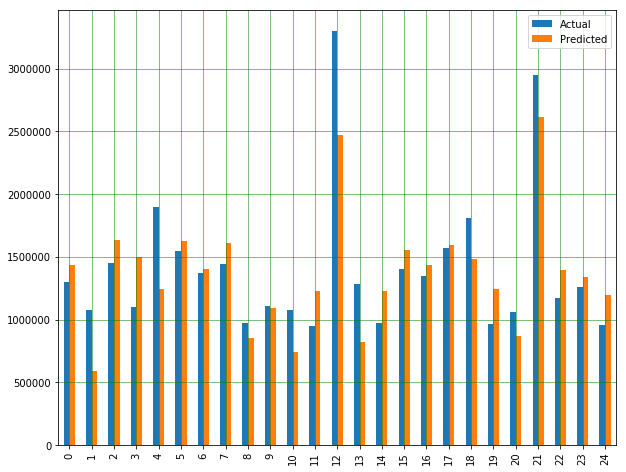

In [66]:
# prediction on test data
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df1 = df.head(25)
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [67]:
# check results
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 319195.35752951197
Mean Squared Error: 165872509696.85416
Root Mean Squared Error: 407274.48937645747


In [68]:
## test the model performance
def linRegcheckModelPerformance(x, y):
    model = LinearRegression()
    # Covert data into train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
                                                        random_state = 7)
    # Build model with train data set
    model.fit(x_train, y_train)
    # Train accuracies
    trainR2 = model.score(x_train, y_train)
    predictedSales = model.predict(x_train)
    mse = metrics.mean_squared_error(predictedSales, y_train)
    trainRmse = np.sqrt(mse)
    trainRmsePct = trainRmse/np.mean(np.mean(np.array(y_train)))*100
    trainAdjR2 = AdjRsquare(model, x_train, y_train)
    trainAccuracies = [len(y_train), trainRmse, trainRmsePct, trainR2, trainAdjR2]
    # Test accuracies
    testR2 = model.score(x_test, y_test)
    predictedSales = model.predict(x_test)
    mse = metrics.mean_squared_error(predictedSales, y_test)
    testRmse = np.sqrt(mse)
    testRmsePct = testRmse/np.mean(np.mean(np.array(y_test)))*100
    testAdjR2 = AdjRsquare(model, x_test, y_test)
    testAccuracies = [len(y_test), testRmse, testRmsePct, testR2, testAdjR2]
    # Create dataframe for results
    resultsDf = pd.DataFrame(index = ["dataSize", "rmse", "rmsePct", "r2", "adjR2"])
    resultsDf['trainData'] = trainAccuracies
    resultsDf['testData'] = testAccuracies
    return ( round(resultsDf, 4))

## Adjusted R^2
def AdjRsquare(modelToBeTested, indData, target):
    Rsquare = modelToBeTested.score(indData, target)
    NoData = len(target)
    p = indData.shape[1]
    tempRsquare = 1 - (1-Rsquare)*(NoData-1)/(NoData - p - 1)
    return tempRsquare

In [69]:
linRegcheckModelPerformance(X, y)

,trainData,testData
dataSize,1424.0000,356.0000
rmse,437127.4493,407274.4894
rmsePct,30.2011,29.2650
r2,0.5192,0.3689
adjR2,0.5141,0.3411


In [70]:
print(cross_val_score(regressor, X, y, scoring='explained_variance', cv=10))

[0.50068561 0.514483   0.43408315 0.59999642 0.52554344 0.42422488
 0.43125996 0.34341726 0.47427512 0.43553892]


In [71]:
print(cross_val_score(regressor, X, y, scoring='neg_mean_absolute_error', cv=10))

[-355820.4505284  -352935.08626131 -322509.97605539 -309484.9759772
 -287625.7660886  -289655.87636111 -317741.59477055 -285208.34979551
 -330568.14048415 -307865.08961761]
